In [ ]:
# Cell 1 - Clone and install
!git clone https://github.com/istat-methodology/terra-package.git
%cd terra-package
!pip install -e .


In [ ]:
# For local use after cloning the repository:
# 1. Open a terminal in the project root
# 2. Run:
#    python -m pip install -e .
# 3. Start from the import cell below

In [1]:
# Cell 2 - Imports
import pandas as pd

from terra_package import (
    TerraDataset,
    NetworkMetricsDataset,
    TimeSeriesDataset,
    load_trade_microdata_from_api,
    analyze_network,
    analyze_basket,
    analyze_series,
    simulate_shock,
    get_terra_classification,
    download_terra_classifications,
)


In [2]:
# Cell 3 - API classifications

products_cpa = get_terra_classification("products_cpa", lang="en")
products_extra = get_terra_classification("products_extra", lang="en")
products_intra = get_terra_classification("products_intra", lang="en")
transports = get_terra_classification("transports", lang="en")

print("products_cpa")
display(products_cpa.head())

print("transports")
display(transports.head())


products_cpa


,id,descr,lang
0,00,All Products,en
1,01,"Products of agriculture, hunting and related s...",en
2,02,"Products of forestry, logging and related serv...",en
3,03,Fish and other fishing products; aquaculture p...,en
4,05,Coal and lignite,en


transports


,id,descr,lang
0,0,Unknown,en
1,1,Sea,en
2,2,Rail,en
3,3,Road,en
4,4,Air,en


In [3]:
# Cell 4 - Save classifications locally

download_terra_classifications(
    output_dir="terra_classifications",
    classifications=[
        "products_extra",
        "products_intra",
        "products_cpa",
        "transports",
    ],
    lang="en",
)


{'products_extra':      id                                    descr lang
 0   011                                  Cereals   en
 1   012                                 Potatoes   en
 2   013                              Sugar beet    en
 3   014         Other fresh fruit and vegetables   en
 4   015         Products of forestry and logging   en
 ..  ...                                      ...  ...
 63  142  Other waste and secondary raw materials   en
 64  175            Other non market goods n.e.c.   en
 65  192               Other unidentifiable goods   en
 66  200     Other goods not elsewhere classified   en
 67  TOT                             All Products   en
 
 [68 rows x 3 columns],
 'products_intra':       id                                              descr lang
 0    011                                Non-perennial crops   en
 1    012                                    Perennial crops   en
 2    013  Planting material: live plants, bulbs, tubers ...   en
 3    014     

In [4]:
# Cell 5 - analyze_network() with precomputed network metrics from TERRA Graph API

base_payload = {
    "percentage": "50",
    "transport": [0, 1, 2, 3, 4, 5, 7, 8, 9],
    "product": "TOT",
    "flow": 0,
    "weight": True,
    "position": None,
    "edges": None,
    "collapse": True,
}

metrics_ds = NetworkMetricsDataset.from_api(
    dataset="Intra",
    base_payload=base_payload,
    start_date="2025-05",
    end_date="2025-05",
    frequency="month",
)

network_out = analyze_network(metrics_ds, base_period="202505")

print(type(network_out), network_out.shape)
display(network_out.head())


Endpoint: https://api.terra.istat.it/graph/graphIntraMonth
Retrieving data for 202505
<class 'pandas.core.frame.DataFrame'> (28, 16)


,Node,Density,degree,Degree,out_degree,Out Degree,in_degree,In Degree,Closeness,Betweenness,Distinctiveness,Period,out_degree_index,betweenness_index,distinctiveness_index,synthetic_index
0,AT,1.0,54,0.043226,27,0.021512,27,0.021714,0.001100,0.000000,0.0,202505,100.0,NaN,NaN,100.0
1,BE,1.0,54,0.104574,27,0.052929,27,0.051646,0.001202,0.037037,0.0,202505,100.0,100.0,NaN,100.0
2,BG,1.0,54,0.009911,27,0.004594,27,0.005318,0.000802,0.000000,0.0,202505,100.0,NaN,NaN,100.0
3,CY,1.0,54,0.001958,27,0.000456,27,0.001502,0.000439,0.000000,0.0,202505,100.0,NaN,NaN,100.0
4,CZ,1.0,54,0.048995,27,0.025759,27,0.023235,0.001071,0.000000,0.0,202505,100.0,NaN,NaN,100.0


In [5]:
# Cell 6 - analyze_basket() with trade microdata from graph/downloadData
# This example uses one valid API payload; researchers can choose another
# product classification, period, flow or measure according to their analysis.

trade_ds = TerraDataset.from_api_microdata(
    product_class="nstr",
    period="202505",
    country="IT",
    partner="AL",
    product="011",
    flow=1,
    criterion=0,
    transport=[1],
    two_values=True,
)

print(trade_ds.data.columns)
display(trade_ds.data.head())

basket_out = analyze_basket(
    trade_ds,
    country="IT",
    partner="AL",
    product="011",
    direction="E",
)

display(basket_out)


Index(['product', 'source', 'target', 'period', 'TRANSPORT_MODE', 'flow',
       'value', 'qty'],
      dtype='object')


,product,source,target,period,TRANSPORT_MODE,flow,value,qty
0,011,IT,AL,202505,1,1,3002,1920


,period,qty
0,202505,1920


Index(['date', 'period', 'series', 'country', 'partner', 'product', 'flow',
       'data_type', 'tipovar'],
      dtype='object')


,date,period,series,country,partner,product,flow,data_type,tipovar
0,2021-10-01,202110,4.415197e+10,IT,AC,00,1,2,1
1,2021-11-01,202111,4.639672e+10,IT,AC,00,1,2,1
2,2021-12-01,202112,4.715061e+10,IT,AC,00,1,2,1
3,2022-01-01,202201,4.805863e+10,IT,AC,00,1,2,1
4,2022-02-01,202202,4.923993e+10,IT,AC,00,1,2,1


dict_keys(['data', 'results', 'models', 'figure', 'axes'])


,period,series,series_ma12,series_trend
0,2021-10-01,4.415197e+10,4.415197e+10,24.618171
1,2021-11-01,4.639672e+10,4.527435e+10,24.628707
2,2021-12-01,4.715061e+10,4.589977e+10,24.638884
3,2022-01-01,4.805863e+10,4.643948e+10,24.648697
4,2022-02-01,4.923993e+10,4.699957e+10,24.658144


dict_keys(['series'])


,term,estimate,std_error,t_value,p_value,conf_low,conf_high,pct_effect
0,Intercept,24.688404,0.022554,1094.657163,0.000000,24.644200,24.732608,NaN
1,t,-0.002431,0.000776,-3.134901,0.001719,-0.003951,-0.000911,NaN
2,D_break,0.028003,0.013812,2.027507,0.042611,0.000933,0.055073,2.839895
3,post_break,0.000367,0.000780,0.470858,0.637742,-0.001162,0.001897,NaN


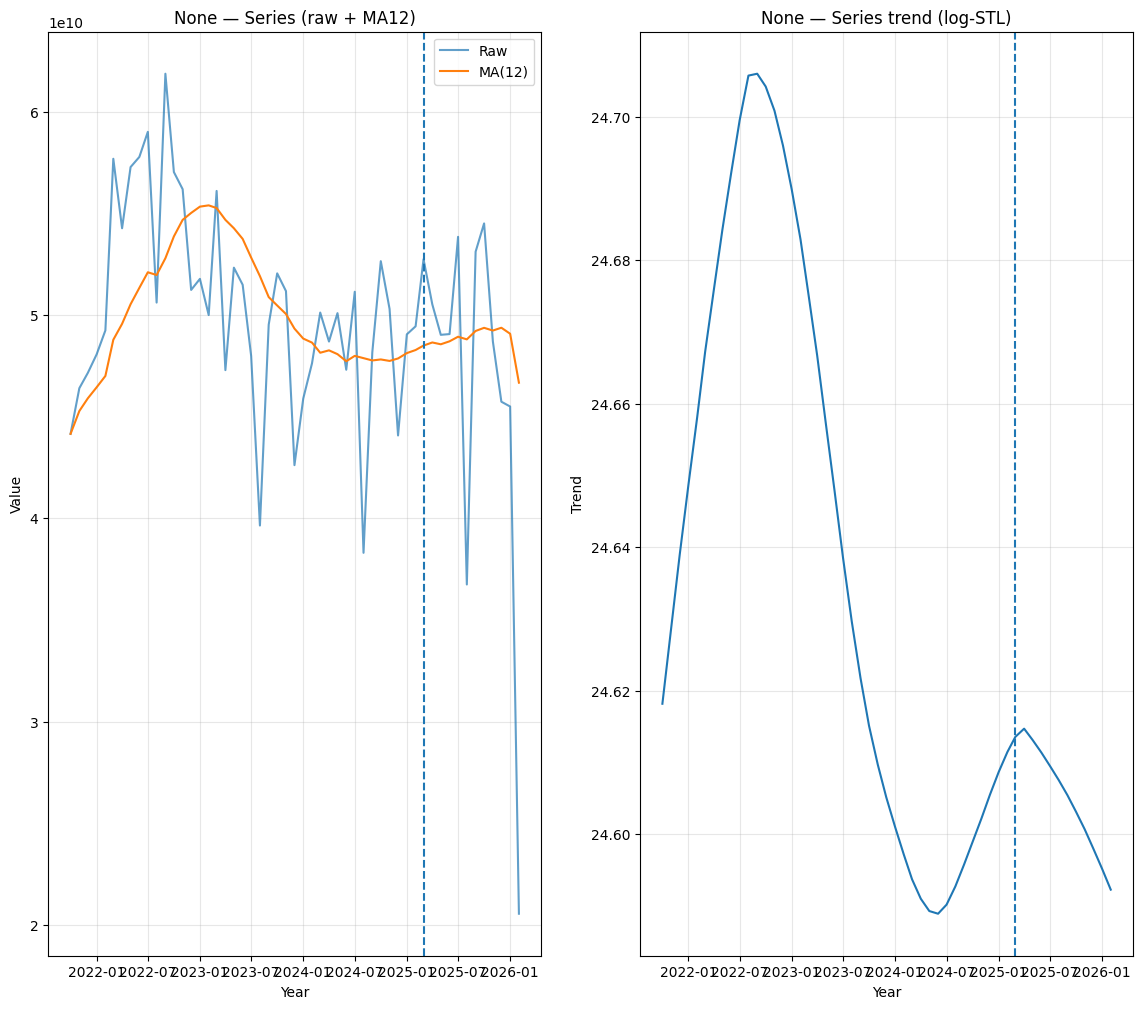

In [6]:
# Cell 7 - analyze_series() with aggregated time series from TERRA time-series API

base_payload = {
    "flow": 1,
    "var": "00",
    "partner": "AC",
    "dataType": 2,
    "tipovar": 1,
    "varType": 1,
}

ts_ds = TimeSeriesDataset.from_api(
    base_payload=base_payload,
    countries=["IT"],
)

print(ts_ds.data.columns)
display(ts_ds.data.head())

series_out = analyze_series(
    ts_ds,
    flow=1,
    break_date="2025-03",
    plot=True,
)

print(series_out.keys())
display(series_out["data"].head())

if series_out["results"] is not None:
    print(series_out["results"].keys())
    display(series_out["results"]["series"])

display(series_out["figure"])


In [7]:
# Cell 8 - simulate_shock() with trade microdata from graph/downloadData
# criterion=0 is used here because CES simulation requires both qty and value.
# This is an API loading choice, not a conceptual constraint on the other analyses.

shock_df = load_trade_microdata_from_api(
    product_class="nstr",
    period="202505",
    country="IT",
    partner=None,
    product="011",
    flow=1,
    criterion=0,
    transport=[1],
)
shock_df = (
    shock_df.groupby(["source", "target", "period", "product", "flow"], as_index=False)
    .agg({"qty": "sum", "value": "sum"})
)
shock_df = shock_df[(shock_df["qty"] > 0) & (shock_df["value"] > 0)].copy()

shock_ds = TerraDataset.from_dataframe(
    shock_df,
    trade_to_network=True,
    mode="import",
    imp_exp=["1", "2"],
    two_values=True,
)

simulated = simulate_shock(
    shock_ds,
    country_from="CA",
    country_to="IT",
    period="202505",
    product="011",
    sigma=2,
)

display(simulated.simulation)


,source,target,period,product,qty,value,price,alpha,share_base,share_post,q_base,q_new,q_delta,scale_factor_qty,qty_new_scale_adjusted,qty_delta_scale_adjusted,qty_redistributed_from_removed,qty_new_constant_total,qty_delta_constant_total
0,AL,IT,202505,011,1920,3002,1.563542,0.000185,0.000023,0.000033,1920.0,2.784290e+03,8.642901e+02,1.0,2.784290e+03,8.642901e+02,4.518994e+03,6.438994e+03,4.518994e+03
1,AR,IT,202505,011,425760,290123,0.681424,0.007795,0.002193,0.003153,425760.0,6.174163e+05,1.916563e+05,1.0,6.174163e+05,1.916563e+05,4.367303e+05,8.624903e+05,4.367303e+05
2,AU,IT,202505,011,54915480,17028369,0.310083,0.208199,0.128692,0.185060,54915480.0,7.963574e+07,2.472026e+07,1.0,7.963574e+07,2.472026e+07,2.563328e+07,8.054876e+07,2.563328e+07
3,BO,IT,202505,011,40000,115160,2.879000,0.013073,0.000870,0.001252,40000.0,5.800604e+04,1.800604e+04,1.0,5.800604e+04,1.800604e+04,1.733536e+05,2.133536e+05,1.733536e+05
4,CA,IT,202505,011,138513256,40303287,0.290971,0.000000,0.304593,0.000000,138513256.0,0.000000e+00,-1.385133e+08,1.0,0.000000e+00,-1.385133e+08,0.000000e+00,0.000000e+00,-1.385133e+08
5,CN,IT,202505,011,52155,78786,1.510613,0.004693,0.000595,0.000856,52155.0,7.563263e+04,2.347763e+04,1.0,7.563263e+04,2.347763e+04,1.185988e+05,1.707538e+05,1.185988e+05
6,GY,IT,202505,011,4395975,1635775,0.372107,0.024000,0.012362,0.017777,4395975.0,6.374828e+06,1.978853e+06,1.0,6.374828e+06,1.978853e+06,2.462378e+06,6.858353e+06,2.462378e+06
7,IN,IT,202505,011,48000,21866,0.455542,0.000393,0.000165,0.000238,48000.0,6.960725e+04,2.160725e+04,1.0,6.960725e+04,2.160725e+04,3.291550e+04,8.091550e+04,3.291550e+04
8,KZ,IT,202505,011,30428643,7734973,0.254200,0.077529,0.058457,0.084062,30428643.0,4.412613e+07,1.369749e+07,1.0,4.412613e+07,1.369749e+07,1.164367e+07,4.207231e+07,1.164367e+07
9,PE,IT,202505,011,243997,662545,2.715382,0.070937,0.005007,0.007200,243997.0,3.538325e+05,1.098355e+05,1.0,3.538325e+05,1.098355e+05,9.973475e+05,1.241344e+06,9.973475e+05


In [8]:
# Cell 9 - Optional: export and reload examples

trade_ds.to_csv("trade_microdata_quantity.csv")
ts_ds.to_csv("time_series.csv")
network_out.to_csv("network_metrics_output.csv", index=False)

reloaded_trade = TerraDataset("trade_microdata_quantity.csv")
reloaded_ts = TimeSeriesDataset.from_csv("time_series.csv")

print("Reloaded trade:", reloaded_trade.data.shape)
print("Reloaded time series:", reloaded_ts.data.shape)


Reloaded trade: (1, 8)
Reloaded time series: (53, 9)
